/home/chenzhiqiang/miniconda3/envs/det/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Start Hybrid Optimization (SA + Remez)... Init L_inf: 0.033342
Iter    0 | Temp: 0.9990 | Loss: 0.18057 | MaxErr(L_inf): 0.03334
Iter  500 | Temp: 0.6058 | Loss: 0.35198 | MaxErr(L_inf): 0.06237
Iter 1000 | Temp: 0.3673 | Loss: 0.31010 | MaxErr(L_inf): 0.05444
Iter 1500 | Temp: 0.2227 | Loss: 0.35565 | MaxErr(L_inf): 0.06440
Iter 2000 | Temp: 0.1351 | Loss: 0.35850 | MaxErr(L_inf): 0.06485
Iter 2500 | Temp: 0.0819 | Loss: 0.34652 | MaxErr(L_inf): 0.06440

 OPTIMIZED HARDWARE PARAMETERS (Decimal Int)
 Final Max Absolute Error (L_inf): 0.033342
Idx  | Start_X (Real)  |  Start_X (Int)  | Slope (Int)  |  Bias (Int)  | Slope (Real) | Bias (Real) 
----------------------------------------------------------------------------------------------------
 0   |         -4.0000 |      -1024      |     -1      |     -3      |   -0.0312    |   -0.0938   
 1   |         -1.9844 |      -508       |     -3      |     -8      |   -0.0938    |   -0.2500   
 2   |         -0.7617 |      -195       |     3   

/tmp/ipykernel_141865/3369051133.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


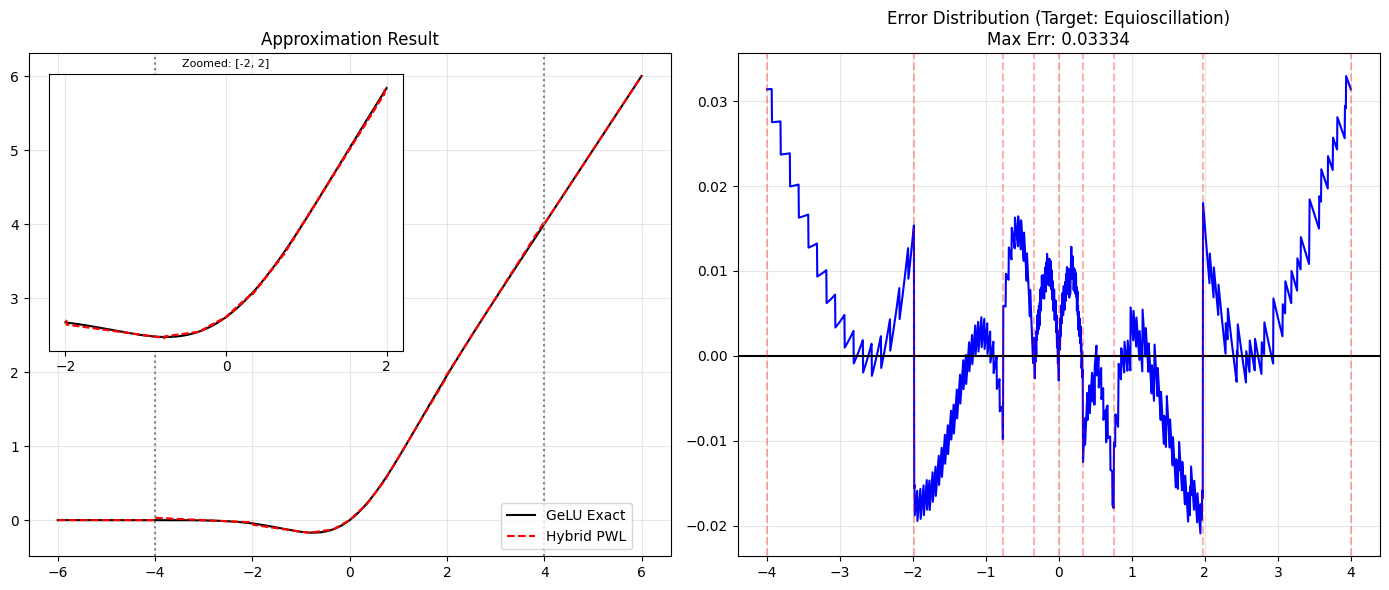

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ==========================================
# 1. Configuration & Quantization Utils
# ==========================================

class FixedPointConfig:
    """
    Configuration for Q M.N fixed point format.
    Total bits = 1 (Sign) + M (Integer) + N (Fraction)
    """
    def __init__(self, m_bits, n_bits):
        self.m = m_bits # Integer bits
        self.n = n_bits # Fractional bits
        self.total_bits = 1 + m_bits + n_bits
        
        # Calculate scaling factor
        self.scale = 2.0 ** self.n
        
        # Calculate value ranges (Float domain)
        self.max_val = (2 ** self.m) - (2 ** (-self.n))
        self.min_val = -(2 ** self.m)
        
        # Calculate integer ranges (Raw integer domain)
        self.min_int = -(1 << (self.total_bits - 1))
        self.max_int = (1 << (self.total_bits - 1)) - 1

def quantize_val(value, config):
    """
    Quantize a floating point value to Q M.N format.
    Process: Float -> Scale -> Round -> Clamp -> De-scale (for simulation)
    """
    # 1. Scale to integer domain
    v_scaled = value * config.scale
    
    # 2. Round to nearest integer (simulate hardware rounding)
    v_int = torch.round(v_scaled)
    
    # 3. Clamp to valid integer range (Saturation)
    v_clamped_int = torch.clamp(v_int, min=config.min_int, max=config.max_int)
    
    # 4. De-scale back to float for loss calculation 
    return v_clamped_int / config.scale

def to_decimal_int(value, config):
    """
    Convert a float value to its underlying decimal integer representation.
    """
    if torch.is_tensor(value):
        v = value.item()
    else:
        v = value
        
    v_scaled = int(round(v * config.scale))
    v_clamped = max(min(v_scaled, config.max_int), config.min_int)
    return v_clamped

# ==========================================
# 2. GeLU & Math Utils
# ==========================================

def gelu_exact(x):
    """Standard GeLU calculation (Ground Truth)."""
    return nn.GELU()(x)

def get_curvature_density(x):
    """
    Calculate the normalized 2nd derivative (curvature) of GeLU.
    Used for initialization and loss weighting.
    """
    x_t = x.clone().requires_grad_(True)
    y = gelu_exact(x_t)
    dy_dx = torch.autograd.grad(y.sum(), x_t, create_graph=True)[0]
    d2y_dx2 = torch.autograd.grad(dy_dx.sum(), x_t)[0]
    return torch.abs(d2y_dx2).detach()

# ==========================================
# 3. PWL Parameter Generation
# ==========================================

def get_quantized_parameters(logits, num_segments, config_x, config_param):
    """
    Convert logits (log-intervals) into quantized breakpoints, slopes, and intercepts.
    """
    weights = torch.softmax(torch.tensor(logits), dim=0)
    
    # Active PWL range fixed to [-4, 4]
    active_min = -4.0
    active_max = 4.0
    total_range = active_max - active_min
    
    intervals = weights * total_range
    
    x_points_float = [active_min]
    for j in range(num_segments):
        next_point = x_points_float[-1] + intervals[j].item()
        x_points_float.append(next_point)
    x_points_float[-1] = active_max
    
    # Quantize breakpoints
    x_points_q = quantize_val(torch.tensor(x_points_float), config_x)
    
    # Calculate Slopes and Intercepts based on Quantized Breakpoints
    # Standard Secant Method: Connect (x_i, y_i) to (x_i+1, y_i+1)
    y_at_breakpoints = gelu_exact(x_points_q)
    
    slopes = []
    intercepts = []
    
    for i in range(len(x_points_q) - 1):
        x_L, x_R = x_points_q[i], x_points_q[i+1]
        y_L, y_R = y_at_breakpoints[i], y_at_breakpoints[i+1]
        
        denom = x_R - x_L
        # Avoid division by zero if quantization collapses an interval
        if denom < (1.0 / config_x.scale):
            k = 0.0 
            b = y_L
        else:
            k = (y_R - y_L) / denom
            b = y_L - k * x_L
            
        slopes.append(k)
        intercepts.append(b)
        
    slopes_q = quantize_val(torch.tensor(slopes), config_param)
    intercepts_q = quantize_val(torch.tensor(intercepts), config_param)
    
    return x_points_q, slopes_q, intercepts_q

def quantized_forward(x_in, x_points_q, slopes_q, intercepts_q, config_x):
    """
    Simulate the hardware inference process with 3 regions:
    1. x < -4: Output 0
    2. -4 <= x <= 4: PWL Approximation
    3. x > 4: Output x (Identity)
    """
    # 1. Quantize Input
    x_q = quantize_val(x_in, config_x)
    
    # Region Masks
    THRESHOLD_LOW = -4.0
    THRESHOLD_HIGH = 4.0

    mask_low = x_q < THRESHOLD_LOW
    mask_high = x_q > THRESHOLD_HIGH
    mask_mid = ~(mask_low | mask_high) 
    
    # --- PWL Logic (Active only for mask_mid) ---
    # Clamp input for lookup safety
    x_clamped_for_lookup = torch.clamp(x_q, min=x_points_q[0], max=x_points_q[-1] - 1e-9)
    
    # Find segment index
    indices = torch.searchsorted(x_points_q, x_clamped_for_lookup, right=True) - 1
    indices = torch.clamp(indices, 0, len(slopes_q) - 1)
    
    k = slopes_q[indices]
    b = intercepts_q[indices]
    
    # Compute Linear: y = kx + b
    y_pwl_raw = k * x_q + b
    
    # --- Combine Regions ---
    y_combined = torch.zeros_like(x_q)
    y_combined += mask_mid * y_pwl_raw
    y_combined += mask_high * x_q # Identity for large positive
    # mask_low is 0.0
    
    # Output quantization
    y_pred_q = quantize_val(y_combined, config_x)
    
    return y_pred_q, x_q, indices

# ==========================================
# 4. Remez-Style Loss & Optimization
# ==========================================

def compute_remez_loss(logits, num_segments, x_samples, config_x, config_param):
    """
    Hybrid Loss Function:
    Combines Weighted L1 (for general fit) with Max Absolute Error (L_inf).
    Minimizing L_inf is the primary goal of Remez algorithm.
    """
    x_points_q, slopes_q, intercepts_q = get_quantized_parameters(logits, num_segments, config_x, config_param)
    
    # 1. Constraint Penalty (Prevent interval collapse)
    intervals = torch.diff(x_points_q)
    min_step = 1.0 / config_x.scale
    violation = torch.relu(min_step - intervals)
    dist_penalty = torch.sum(violation) * 10000.0
        
    # 2. Forward Pass
    y_pred, _, indices = quantized_forward(x_samples, x_points_q, slopes_q, intercepts_q, config_x)
    y_true = gelu_exact(x_samples)
    abs_error = torch.abs(y_pred - y_true)
    
    # 3. Max Error (L_inf Norm) - The Remez Objective
    max_error = torch.max(abs_error)
    
    # 4. Weighted Average Error (for global smoothness)
    curvature = get_curvature_density(x_samples)
    curvature_weights = 1.0 + 3.0 * (curvature / (curvature.max() + 1e-6))
    weighted_mae = torch.mean(abs_error * curvature_weights)
    
    # Combine: Heavily weight the Max Error to mimic Minimax behavior
    total_loss = weighted_mae + (5.0 * max_error) + dist_penalty
    
    # Return detailed stats for the guided perturbation step
    return total_loss.item(), max_error.item(), abs_error, indices, x_points_q

def init_logits_by_curvature(num_segments):
    """Initialize based on curvature density (Standard CDF inverse method)."""
    x_grid = torch.linspace(-4.0, 4.0, 1000)
    curv = get_curvature_density(x_grid)
    
    pdf = curv + 0.1 # Add baseline uniformity
    pdf = pdf / pdf.sum()
    cdf = torch.cumsum(pdf, dim=0)
    cdf = cdf / cdf[-1]
    
    target_cdfs = np.linspace(0, 1, num_segments + 1)
    x_initial = np.interp(target_cdfs, cdf.numpy(), x_grid.numpy())
    
    intervals = np.diff(x_initial)
    logits = np.log(intervals + 1e-6)
    return logits

def optimize_quantized_gelu_hybrid(num_segments=8, iterations=3000):
    # Quantization Settings
    cfg_x = FixedPointConfig(m_bits=7, n_bits=8) # Input/Output
    cfg_p = FixedPointConfig(m_bits=2, n_bits=5) # Parameters
    
    # High-resolution sampling for optimization
    x_samples = torch.linspace(-4.0, 4.0, 8000)
    
    # Initialization
    current_logits = init_logits_by_curvature(num_segments)
    current_loss, current_max_err, _, _, _ = compute_remez_loss(current_logits, num_segments, x_samples, cfg_x, cfg_p)
    
    best_logits = current_logits.copy()
    best_loss = current_loss
    best_max_err = current_max_err
    
    temp = 1.0
    cooling_rate = 0.999
    
    print(f"Start Hybrid Optimization (SA + Remez)... Init L_inf: {current_max_err:.6f}")
    
    for i in range(iterations):
        # 1. Calculate Error Distribution per Segment (Remez Step)
        # We need to know which segments are contributing most to the error
        _, _, abs_errors, indices, _ = compute_remez_loss(current_logits, num_segments, x_samples, cfg_x, cfg_p)
        
        # Calculate max error within each segment
        segment_max_errors = np.zeros(num_segments)
        for seg_idx in range(num_segments):
            # Mask for samples falling into segment 'seg_idx'
            mask = (indices == seg_idx)
            if mask.sum() > 0:
                segment_max_errors[seg_idx] = torch.max(abs_errors[mask]).item()
        
        avg_segment_error = np.mean(segment_max_errors)
        
        # 2. Determine Perturbation Vector
        # SA Logic: Random noise
        noise = np.random.randn(num_segments)
        
        # Remez Logic: 
        # If segment error > average, we want to SHRINK the interval (reduce logit).
        # Shrinking interval -> higher density of breakpoints -> lower approximation error.
        # If segment error < average, we EXPAND (increase logit) to give space to others.
        remez_direction = -(segment_max_errors - avg_segment_error)
        
        # Blend Random and Remez based on Temperature
        # High Temp -> Mostly Random (Global Search)
        # Low Temp -> Mostly Remez (Local Refinement/Equioscillation)
        remez_strength = 2.0 * (1.0 - temp) # Increases as temp decreases
        perturbation = (noise * temp) + (remez_direction * remez_strength)
        
        # Apply perturbation
        new_logits = current_logits + (perturbation * 0.1) # Learning rate scaling
        
        # 3. Evaluate
        new_loss, new_max_err, _, _, _ = compute_remez_loss(new_logits, num_segments, x_samples, cfg_x, cfg_p)
        
        # 4. Metropolis Acceptance Criterion
        if new_loss < current_loss:
            accept = True
        else:
            delta = new_loss - current_loss
            prob = math.exp(-delta / (temp * 0.1 + 1e-6))
            accept = random.random() < prob
            
        if accept:
            current_logits = new_logits
            current_loss = new_loss
            current_max_err = new_max_err
            if current_loss < best_loss:
                best_loss = current_loss
                best_logits = new_logits.copy()
                best_max_err = current_max_err
        
        temp *= cooling_rate
        
        if i % 500 == 0:
            print(f"Iter {i:4d} | Temp: {temp:.4f} | Loss: {current_loss:.5f} | MaxErr(L_inf): {current_max_err:.5f}")

    # ==========================================
    # 5. Export & Visualize
    # ==========================================
    final_x, final_slopes, final_intercepts = get_quantized_parameters(best_logits, num_segments, cfg_x, cfg_p)
    
    print("\n" + "="*100)
    print(" OPTIMIZED HARDWARE PARAMETERS (Decimal Int)")
    print(f" Final Max Absolute Error (L_inf): {best_max_err:.6f}")
    print("="*100)
    print(f"{'Idx':^4} | {'Start_X (Real)':^15} | {'Start_X (Int)':^15} | {'Slope (Int)':^12} | {'Bias (Int)':^12} | {'Slope (Real)':^12} | {'Bias (Real)':^12}")
    print("-" * 100)
    
    for i in range(num_segments):
        x_int = to_decimal_int(final_x[i], cfg_x)
        s_int = to_decimal_int(final_slopes[i], cfg_p)
        b_int = to_decimal_int(final_intercepts[i], cfg_p)
        print(f"{i:^4} | {final_x[i].item():15.4f} | {x_int:^15d} |{s_int:^12d} |{b_int:^12d} | {final_slopes[i].item():^12.4f} | {final_intercepts[i].item():^12.4f}")
        
    # Visualization
    plt.figure(figsize=(14, 6))

    # 1. Function Plot (with zoom-in inset)
    ax1 = plt.subplot(1, 2, 1)
    x_plot = torch.linspace(-6.0, 6.0, 2000)
    y_true = gelu_exact(x_plot)
    y_pred, _, _ = quantized_forward(x_plot, final_x, final_slopes, final_intercepts, cfg_x)

    plt.plot(x_plot, y_true, 'k', label='GeLU Exact')
    plt.plot(x_plot, y_pred, 'r--', label='Hybrid PWL')
    # plt.legend(loc='lower right')
    plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0))
    plt.axvline(-4, color='gray', linestyle=':')
    plt.axvline(4, color='gray', linestyle=':')
    plt.title("Approximation Result")
    plt.grid(True, alpha=0.3)

    # === NEW: Add zoomed-in view at top-left corner ===
    inset_ax = inset_axes(ax1,
                      width="55%",   # width as percentage of parent axis
                      height="55%",  # height as percentage
                      loc='upper left',  # position inside ax1
                      borderpad=1.5)     # padding from edge

    # Then plot zoomed content
    x_zoom = torch.linspace(-2.0, 2.0, 2000)
    y_true_zoom = gelu_exact(x_zoom)
    y_pred_zoom, _, _ = quantized_forward(x_zoom, final_x, final_slopes, final_intercepts, cfg_x)
    inset_ax.plot(x_zoom, y_true_zoom, 'k', linewidth=1.5)
    inset_ax.plot(x_zoom, y_pred_zoom, 'r--', linewidth=1.5)
    inset_ax.set_title('Zoomed: [-2, 2]', fontsize=8)
    inset_ax.grid(True, alpha=0.3)
    inset_ax.set_xticks([-2, 0, 2])
    inset_ax.set_yticks([])
    # === END NEW ===

    # 2. Error Plot (Demonstrating Equioscillation)
    plt.subplot(1, 2, 2)
    x_active = torch.linspace(-4.0, 4.0, 2000)
    y_active_true = gelu_exact(x_active)
    y_active_pred, _, _ = quantized_forward(x_active, final_x, final_slopes, final_intercepts, cfg_x)
    error = y_active_pred - y_active_true

    plt.plot(x_active, error, 'b')
    plt.axhline(0, color='k')
    plt.title(f"Error Distribution (Target: Equioscillation)\nMax Err: {best_max_err:.5f}")
    plt.grid(True, alpha=0.3)

    # Plot breakpoints on error graph
    for bp in final_x:
        plt.axvline(bp, color='r', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()


optimize_quantized_gelu_hybrid(num_segments=8, iterations=3000)

In [2]:
# x_sub_rg = torch.linspace(-2.0, 2.0, 2000)
# y_active_true_sub_rg = gelu_exact(x_sub_rg)
# y_active_pred_sub_rg, _, _ = quantized_forward(x_sub_rg, final_x, final_slopes, final_intercepts, cfg_x)
# error_sub_rg = y_active_pred_sub_rg - y_active_true_sub_rg

# plt.plot(x_sub_rg, error_sub_rg, 'b')
